In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

In [5]:
# Fetch the data.
df = pd.read_csv("https://ourworldindata.org/grapher/children-born-per-woman.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

# Fetch the metadata
metadata = requests.get("https://ourworldindata.org/grapher/children-born-per-woman.metadata.json?v=1&csvType=full&useColumnShortNames=true").json()

In [6]:
df.head()


,entity,code,year,fertility_rate_hist
0,Afghanistan,AFG,1950,7.248
1,Afghanistan,AFG,1951,7.260
2,Afghanistan,AFG,1952,7.260
3,Afghanistan,AFG,1953,7.266
4,Afghanistan,AFG,1954,7.254


In [7]:
japon = df[df['entity'] == 'Japan']
japon


,entity,code,year,fertility_rate_hist
8384,Japan,JPN,1947,4.614
8385,Japan,JPN,1948,4.463
8386,Japan,JPN,1949,4.373
8387,Japan,JPN,1950,3.615
8388,Japan,JPN,1951,3.225
...,...,...,...,...
8456,Japan,JPN,2019,1.323
8457,Japan,JPN,2020,1.304
8458,Japan,JPN,2021,1.275
8459,Japan,JPN,2022,1.256


In [8]:
mexico = df[df['entity'] == 'Mexico']
mexico

,entity,code,year,fertility_rate_hist
11125,Mexico,MEX,1950,6.709
11126,Mexico,MEX,1951,6.727
11127,Mexico,MEX,1952,6.731
11128,Mexico,MEX,1953,6.734
11129,Mexico,MEX,1954,6.745
...,...,...,...,...
11194,Mexico,MEX,2019,2.020
11195,Mexico,MEX,2020,1.990
11196,Mexico,MEX,2021,1.970
11197,Mexico,MEX,2022,1.940


In [9]:
anios_japon = japon['year'].to_numpy()
tasa_japon = japon['fertility_rate_hist'].to_numpy()

In [10]:
anios_mexico = mexico['year'].to_numpy()
tasa_mexico = mexico['fertility_rate_hist'].to_numpy()

In [11]:
type(anios_japon), type(tasa_japon), type(anios_mexico), type(tasa_mexico)

(numpy.ndarray, numpy.ndarray, numpy.ndarray, numpy.ndarray)

In [12]:
promedio_japon = np.mean(tasa_japon)
promedio_mexico = np.mean(tasa_mexico)

In [13]:
minimo_japon = np.min(tasa_japon)
minimo_mexico = np.min(tasa_mexico)

In [14]:
maximo_japon = np.max(tasa_japon)
maximo_mexico = np.max(tasa_mexico)

In [15]:
desviacion_japon = np.std(tasa_japon)
desviacion_mexico = np.std(tasa_mexico)

In [16]:
plt.Figure(figsize=(10, 5))

<Figure size 1000x500 with 0 Axes>

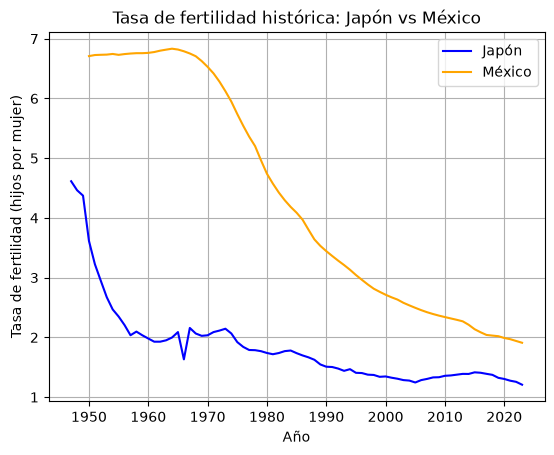

In [17]:
plt.plot(anios_japon, tasa_japon, label='Japón', color='blue')
plt.plot(anios_mexico, tasa_mexico, label='México', color='orange')
plt.title('Tasa de fertilidad histórica: Japón vs México')
plt.xlabel('Año')
plt.ylabel('Tasa de fertilidad (hijos por mujer)')
plt.grid(True)
plt.legend()

In [24]:
mascara_coincidencia_anios = anios_japon >= anios_mexico.min()

In [25]:
mascara_coincidencia_anios.shape

(77,)

In [26]:
mascara_coincidencia_anios

array([False, False, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [27]:
anios_japon = anios_japon[mascara_coincidencia_anios]

In [28]:
tasa_japon = tasa_japon[mascara_coincidencia_anios]

In [29]:
diferencia_mx_jp = tasa_mexico - tasa_japon

In [30]:
diferencia_mx_jp

array([3.094, 3.502, 3.784, 4.061, 4.277, 4.381, 4.537, 4.716, 4.661,
       4.723, 4.782, 4.849, 4.872, 4.866, 4.835, 4.73 , 5.158, 4.595,
       4.642, 4.6  , 4.494, 4.33 , 4.167, 3.976, 3.882, 3.818, 3.702,
       3.572, 3.416, 3.195, 3.   , 2.856, 2.687, 2.526, 2.404, 2.351,
       2.273, 2.137, 2.015, 1.985, 1.935, 1.859, 1.807, 1.771, 1.664,
       1.637, 1.561, 1.51 , 1.444, 1.423, 1.368, 1.346, 1.325, 1.294,
       1.259, 1.25 , 1.171, 1.116, 1.061, 1.031, 0.983, 0.954, 0.918,
       0.88 , 0.823, 0.722, 0.678, 0.651, 0.657, 0.697, 0.686, 0.695,
       0.684, 0.702])

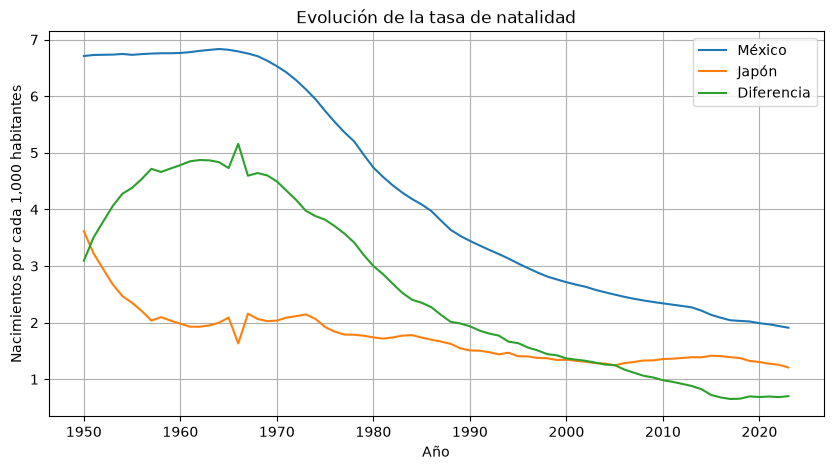

In [31]:
plt.figure(figsize=(10,5))

plt.plot(
    anios_mexico,
    tasa_mexico,
    label = "México"
)

plt.plot(
    anios_japon,
    tasa_japon,
    label = "Japón"
)

plt.plot(
    anios_mexico,
    diferencia_mx_jp,
    label = "Diferencia"
)


plt.title("Evolución de la tasa de natalidad")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

In [39]:
brasil= df[df['entity'] == 'Brazil']
brasil

,entity,code,year,fertility_rate_hist
2371,Brazil,BRA,1950,6.122
2372,Brazil,BRA,1951,6.115
2373,Brazil,BRA,1952,6.102
2374,Brazil,BRA,1953,6.093
2375,Brazil,BRA,1954,6.087
...,...,...,...,...
2440,Brazil,BRA,2019,1.705
2441,Brazil,BRA,2020,1.653
2442,Brazil,BRA,2021,1.638
2443,Brazil,BRA,2022,1.629


In [40]:
anios_brasil = brasil['year'].to_numpy()

tasa_brasil = brasil['fertility_rate_hist'].to_numpy()

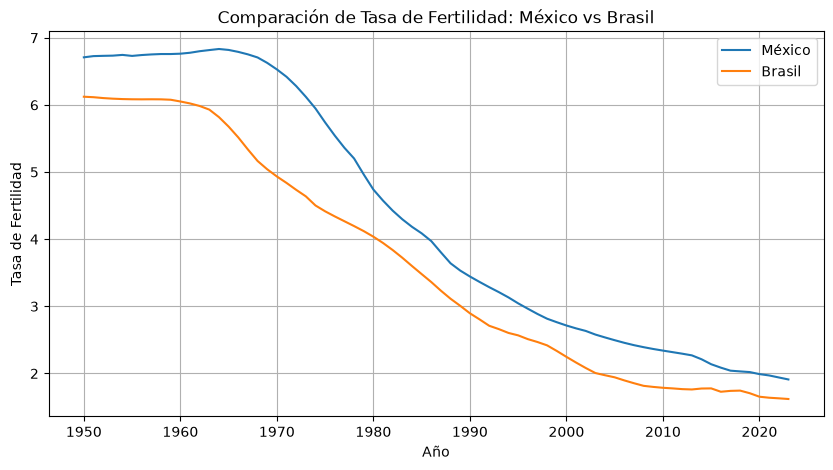

In [41]:

plt.figure(figsize=(10,5))

plt.plot(
    anios_mexico,
    tasa_mexico,
    label = "México"
)

plt.plot(
    anios_brasil,
    tasa_brasil,
    label = "Brasil"
)
plt.xlabel("Año")
plt.ylabel("Tasa de Fertilidad")
plt.title("Comparación de Tasa de Fertilidad: México vs Brasil")
plt.legend()
plt.grid(True)

In [42]:
anios_comunes = np.intersect1d(anios_mexico, anios_brasil)

In [43]:
anios_comunes

array([1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960,
       1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

OTRA FORMA DE FILTRAR DATOS CON PANDAS

In [44]:
comparacion_mexico_japon = pd.merge(
    mexico[['year', 'fertility_rate_hist']],
    japon[['year', 'fertility_rate_hist']],
    on='year',
    suffixes=('_mexico', '_japon')
)
